In [1]:
# ── Step 1: Imports + Configuration ───────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)

# ── Model & data parameters ────────────────────────────────────────────────────
TICKER        = "AAPL"
PERIOD        = "2y"
TEST_DAYS     = 30
FORECAST_DAYS = 15

WINDOW_SIZE   = 60     # past days used for prediction
BATCH_SIZE    = 32
EPOCHS        = 25

print("Step 1 complete.")

Step 1 complete.


In [2]:
# ── Step 2: Download data ─────────────────────────────────────────────────────

df = yf.download(TICKER, period=PERIOD)

df = df[['Close', 'Volume']].dropna()

print(df.tail())
print("Step 2 complete.")

[*********************100%***********************]  1 of 1 completed

Price            Close    Volume
Ticker            AAPL      AAPL
Date                            
2026-03-09  259.880005  38218500
2026-03-10  260.829987  30590800
2026-03-11  260.809998  26218900
2026-03-12  255.759995  40794000
2026-03-13  250.119995  36929988
Step 2 complete.


In [3]:
# ── Step 3: Train/Test Split ──────────────────────────────────────────────────

train_df = df[:-TEST_DAYS]
test_df  = df[-TEST_DAYS:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (471, 2)
Test shape: (30, 2)


In [4]:
# ── Step 4: Scaling ───────────────────────────────────────────────────────────

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
test_scaled  = scaler.transform(test_df)

print("Step 4 complete.")

Step 4 complete.


In [5]:
# ── Step 5: Sliding window function ───────────────────────────────────────────

def create_windows(data, window_size):
    X, y = [], []
    
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 0])   # predict Close
    
    return np.array(X), np.array(y)

X_train, y_train = create_windows(train_scaled, WINDOW_SIZE)

# Important: include context from train when building test
combined = np.vstack([train_scaled[-WINDOW_SIZE:], test_scaled])
X_test, y_test = create_windows(combined, WINDOW_SIZE)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (411, 60, 2)
X_test: (30, 60, 2)


In [6]:
# ── Step 6: Build GRU model ───────────────────────────────────────────────────

model = Sequential([
    GRU(64, return_sequences=True, input_shape=(WINDOW_SIZE, X_train.shape[2])),
    Dropout(0.2),
    
    GRU(32),
    Dropout(0.2),
    
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

C:\Users\LENOVO\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 60, 64)              │          13,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,497 (87.88 KB)

 Trainable params: 22,497 (87.88 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ── Step 8: Evaluation ────────────────────────────────────────────────────────

pred_scaled = model.predict(X_test)

# inverse scaling (only Close column)
dummy = np.zeros((len(pred_scaled), train_df.shape[1]))
dummy[:,0] = pred_scaled[:,0]

pred_prices = scaler.inverse_transform(dummy)[:,0]
actual_prices = test_df['Close'].values

rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
mae  = mean_absolute_error(actual_prices, pred_prices)

print("RMSE:", rmse)
print("MAE :", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
RMSE: 91.35703072363299
MAE : 91.09161966927816


In [8]:
# ── Step 9: Forecast future ───────────────────────────────────────────────────

last_window = combined[-WINDOW_SIZE:]
future_preds = []

for _ in range(FORECAST_DAYS):
    pred = model.predict(last_window[np.newaxis,:,:])[0,0]
    future_preds.append(pred)
    
    new_row = last_window[-1].copy()
    new_row[0] = pred
    
    last_window = np.vstack([last_window[1:], new_row])

# inverse scale
dummy = np.zeros((len(future_preds), train_df.shape[1]))
dummy[:,0] = future_preds

future_prices = scaler.inverse_transform(dummy)[:,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


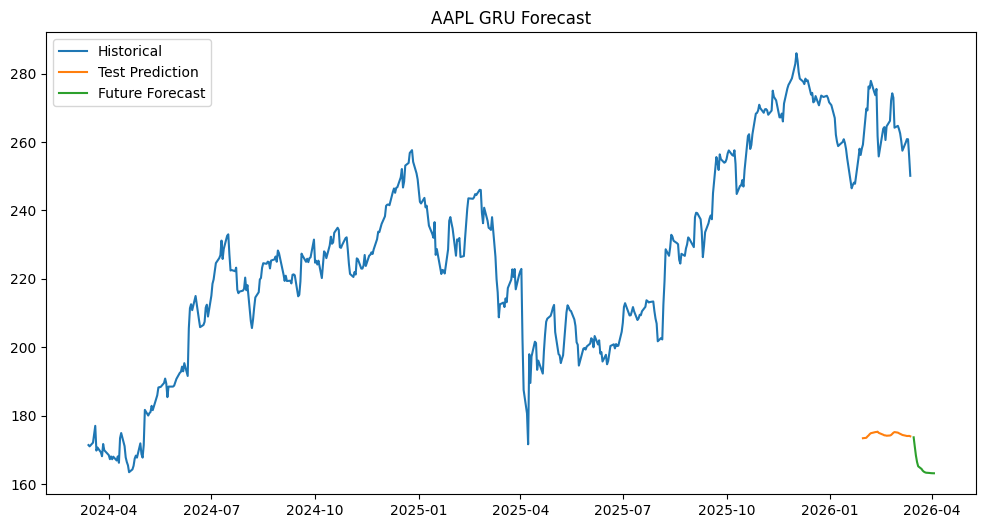

In [9]:
# ── Step 10: Plot ─────────────────────────────────────────────────────────────

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label="Historical")
plt.plot(test_df.index, pred_prices, label="Test Prediction")

future_index = pd.date_range(df.index[-1], periods=FORECAST_DAYS+1, freq="B")[1:]
plt.plot(future_index, future_prices, label="Future Forecast")

plt.legend()
plt.title(f"{TICKER} GRU Forecast")
plt.show()

[*********************100%***********************]  1 of 1 completed

Epoch 1/60



C:\Users\LENOVO\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 0.0119 - val_loss: 2.4962e-04
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0020 - val_loss: 3.6944e-04
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0014 - val_loss: 3.4240e-04
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0013 - val_loss: 2.6955e-04
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0012 - val_loss: 2.6336e-04
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 0.0011 - val_loss: 2.3334e-04
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 9.5676e-04 - val_loss: 2.4994e-04
Epoch 8/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 8.8704e-04 - val_loss: 2.0052e-04
Epoch 9/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 9.0158e-04 - val_loss: 2.0089e-04
Epoch 10/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 9.4906e-04 - val_loss: 2.0860e-04
Epoch 11/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 8.4494e-04 - val_loss: 1.9525e-0

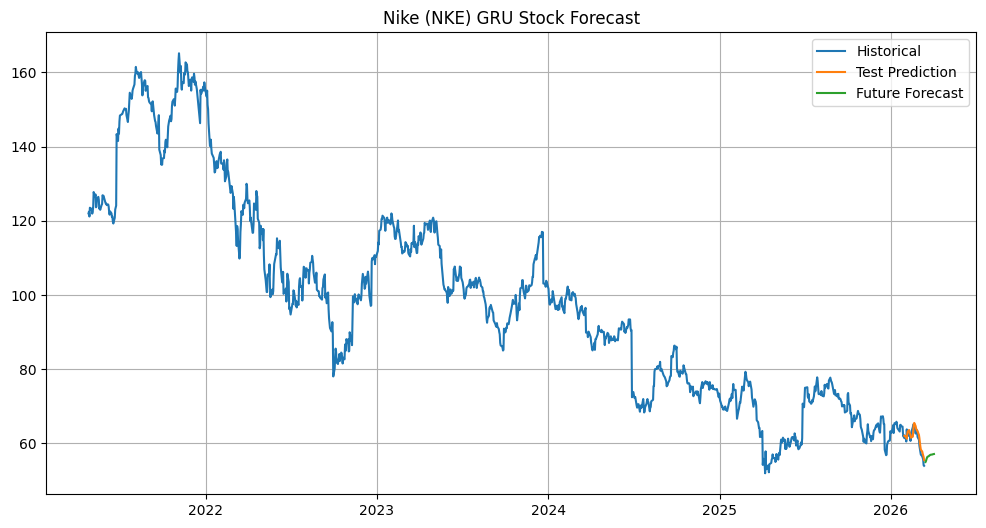

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Full GRU Stock Forecast Pipeline (Nike - NKE)
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# ── Parameters ───────────────────────────────────────────────────────────────
TICKER = "NKE"
PERIOD = "5y"
TEST_DAYS = 30
FORECAST_DAYS = 15
WINDOW_SIZE = 90
EPOCHS = 60
BATCH_SIZE = 32

# ── Download data ────────────────────────────────────────────────────────────
df = yf.download(TICKER, period=PERIOD)

# Technical indicators
df["SMA10"] = df["Close"].rolling(10).mean()
df["SMA30"] = df["Close"].rolling(30).mean()
df["EMA12"] = df["Close"].ewm(span=12).mean()
df["EMA26"] = df["Close"].ewm(span=26).mean()
df["MACD"] = df["EMA12"] - df["EMA26"]

df = df[["Close","Volume","SMA10","SMA30","MACD"]].dropna()

# ── Train/Test split ─────────────────────────────────────────────────────────
train_df = df[:-TEST_DAYS]
test_df = df[-TEST_DAYS:]

# ── Scaling ──────────────────────────────────────────────────────────────────
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

# ── Window creation ──────────────────────────────────────────────────────────
def create_windows(data, window):
    X,y = [],[]
    for i in range(window,len(data)):
        X.append(data[i-window:i])
        y.append(data[i,0])
    return np.array(X), np.array(y)

X_train, y_train = create_windows(train_scaled, WINDOW_SIZE)

combined = np.vstack([train_scaled[-WINDOW_SIZE:], test_scaled])
X_test, y_test = create_windows(combined, WINDOW_SIZE)

# ── GRU Model ────────────────────────────────────────────────────────────────
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(WINDOW_SIZE,X_train.shape[2])),
    Dropout(0.3),

    GRU(64, return_sequences=True),
    Dropout(0.3),

    GRU(32),
    Dense(1)
])

model.compile(optimizer="adam", loss=tf.keras.losses.Huber())

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

model.fit(
    X_train,y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ── Test prediction ──────────────────────────────────────────────────────────
pred_scaled = model.predict(X_test)

dummy = np.zeros((len(pred_scaled),train_df.shape[1]))
dummy[:,0] = pred_scaled[:,0]

pred_prices = scaler.inverse_transform(dummy)[:,0]
actual_prices = test_df["Close"].values

rmse = np.sqrt(mean_squared_error(actual_prices,pred_prices))
mae = mean_absolute_error(actual_prices,pred_prices)

print("RMSE:",rmse)
print("MAE:",mae)

# ── Future forecasting ───────────────────────────────────────────────────────
last_window = combined[-WINDOW_SIZE:]
future_preds = []

for _ in range(FORECAST_DAYS):

    pred = model.predict(last_window[np.newaxis,:,:])[0,0]
    future_preds.append(pred)

    new_row = last_window[-1].copy()
    new_row[0] = pred

    last_window = np.vstack([last_window[1:],new_row])

dummy = np.zeros((len(future_preds),train_df.shape[1]))
dummy[:,0] = future_preds

future_prices = scaler.inverse_transform(dummy)[:,0]

future_index = pd.date_range(df.index[-1],periods=FORECAST_DAYS+1,freq="B")[1:]

# ── Plot results ─────────────────────────────────────────────────────────────
plt.figure(figsize=(12,6))

plt.plot(df.index,df["Close"],label="Historical")
plt.plot(test_df.index,pred_prices,label="Test Prediction")

plt.plot(future_index,future_prices,label="Future Forecast")

plt.title("Nike (NKE) GRU Stock Forecast")
plt.legend()
plt.grid(True)

plt.show()

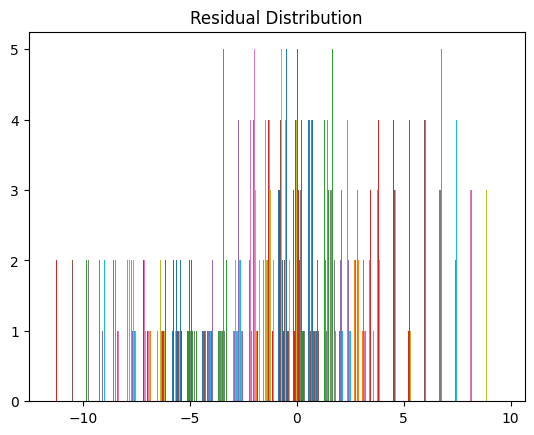

In [11]:
residuals = actual_prices - pred_prices
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

[*********************100%***********************]  1 of 1 completed
C:\Users\LENOVO\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step


[*********************100%***********************]  1 of 1 completed


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


[*********************100%***********************]  1 of 1 completed
C:\Users\LENOVO\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step


[*********************100%***********************]  1 of 1 completed


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
NKE RMSE: 0.019984287053101894
NKE MAE : 0.016204452946075358

ADDYY RMSE: 0.01734046089022561
ADDYY MAE : 0.013482393773851223



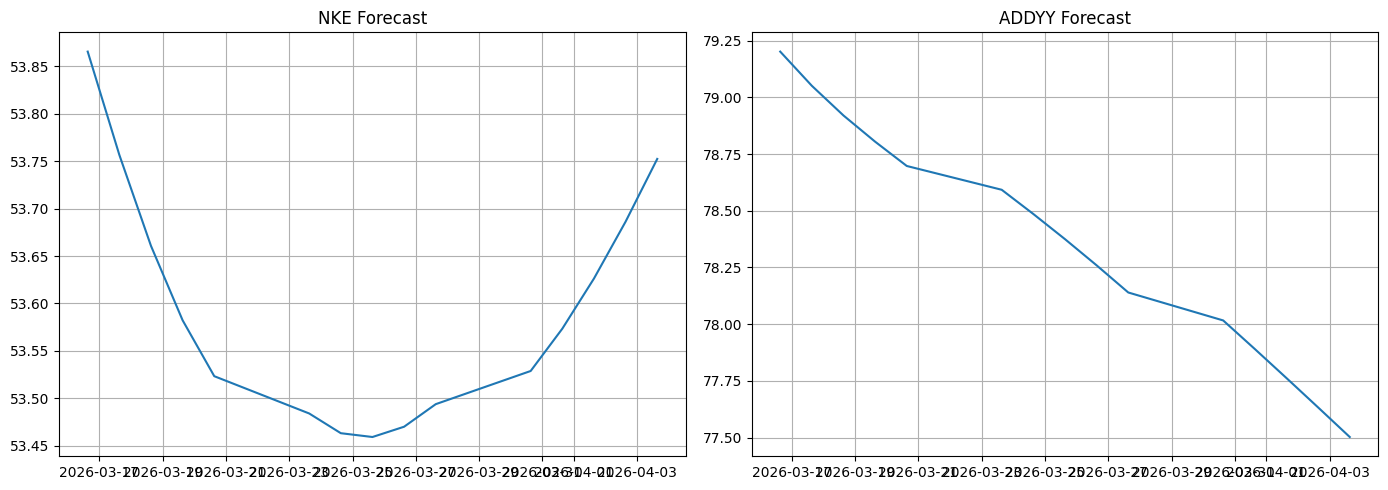

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# GRU Return Prediction: Nike vs Adidas
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# ── Parameters ───────────────────────────────────────────────────────────────
TICKERS = ["NKE","ADDYY"]
PERIOD = "5y"
TEST_DAYS = 30
FORECAST_DAYS = 15
WINDOW = 90
EPOCHS = 50
BATCH = 32

results = {}

for ticker in TICKERS:

    # ── Download data ───────────────────────────────────────────────────────
    df = yf.download(ticker, period=PERIOD)

    # Technical indicators
    df["SMA10"] = df["Close"].rolling(10).mean()
    df["SMA30"] = df["Close"].rolling(30).mean()
    df["EMA12"] = df["Close"].ewm(span=12).mean()
    df["EMA26"] = df["Close"].ewm(span=26).mean()
    df["MACD"] = df["EMA12"] - df["EMA26"]

    # Returns target
    df["Return"] = df["Close"].pct_change()

    df = df[["Return","Volume","SMA10","SMA30","MACD"]].dropna()

    # ── Train/Test split ────────────────────────────────────────────────────
    train_df = df[:-TEST_DAYS]
    test_df = df[-TEST_DAYS:]

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_df)
    test_scaled = scaler.transform(test_df)

    # ── Window creation ─────────────────────────────────────────────────────
    def make_windows(data,window):
        X,y=[],[]
        for i in range(window,len(data)):
            X.append(data[i-window:i])
            y.append(data[i,0])
        return np.array(X),np.array(y)

    X_train,y_train = make_windows(train_scaled,WINDOW)

    combined = np.vstack([train_scaled[-WINDOW:],test_scaled])
    X_test,y_test = make_windows(combined,WINDOW)

    # ── GRU Model ───────────────────────────────────────────────────────────
    model = Sequential([
        GRU(128,return_sequences=True,input_shape=(WINDOW,X_train.shape[2])),
        Dropout(0.3),
        GRU(64,return_sequences=True),
        Dropout(0.3),
        GRU(32),
        Dense(1)
    ])

    model.compile(optimizer="adam",loss=tf.keras.losses.Huber())

    early_stop = EarlyStopping(patience=8,restore_best_weights=True)

    model.fit(
        X_train,y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    # ── Test prediction ─────────────────────────────────────────────────────
    pred_scaled = model.predict(X_test)

    dummy = np.zeros((len(pred_scaled),train_df.shape[1]))
    dummy[:,0] = pred_scaled[:,0]

    pred_returns = scaler.inverse_transform(dummy)[:,0]
    actual_returns = test_df["Return"].values

    rmse = np.sqrt(mean_squared_error(actual_returns,pred_returns))
    mae = mean_absolute_error(actual_returns,pred_returns)

    # ── Convert return forecast → price forecast ────────────────────────────
    last_price = yf.download(ticker,period="1d")["Close"].iloc[-1]

    future_returns = []
    last_window = combined[-WINDOW:]

    for _ in range(FORECAST_DAYS):

        pred = model.predict(last_window[np.newaxis,:,:])[0,0]
        future_returns.append(pred)

        new_row = last_window[-1].copy()
        new_row[0] = pred

        last_window = np.vstack([last_window[1:],new_row])

    dummy = np.zeros((len(future_returns),train_df.shape[1]))
    dummy[:,0] = future_returns

    future_returns = scaler.inverse_transform(dummy)[:,0]

    future_prices=[last_price]

    for r in future_returns:
        future_prices.append(future_prices[-1]*(1+r))

    future_prices=future_prices[1:]

    future_index = pd.date_range(
        pd.Timestamp.today(),
        periods=FORECAST_DAYS,
        freq="B"
    )

    results[ticker]={
        "rmse":rmse,
        "mae":mae,
        "future_index":future_index,
        "future_prices":future_prices
    }

# ── Plot side-by-side forecasts ─────────────────────────────────────────────
fig,ax = plt.subplots(1,2,figsize=(14,5))

for i,ticker in enumerate(TICKERS):

    ax[i].plot(
        results[ticker]["future_index"],
        results[ticker]["future_prices"]
    )

    ax[i].set_title(f"{ticker} Forecast")
    ax[i].grid(True)

    print(ticker,"RMSE:",results[ticker]["rmse"])
    print(ticker,"MAE :",results[ticker]["mae"])
    print()

plt.tight_layout()
plt.show()